In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def generate_gmm_samples(means, variance=0.05, num_samples_per_mode=100):
    """주어진 중심점(means)들을 바탕으로 GMM 데이터를 샘플링합니다."""
    samples = []
    for mu in means:
        # 각 중심점 주변으로 가우시안 노이즈(variance)를 주입하여 점들을 생성
        noise = np.random.randn(num_samples_per_mode, 2) * np.sqrt(variance)
        samples.append(mu + noise)
    return np.vstack(samples)

### 2D Grid

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_21323/313992109.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.scatter(grid_means[:, 0], grid_means[:, 1], color='red', edgecolor='black', s=80, label='Gaussian Means ($\mu$)')


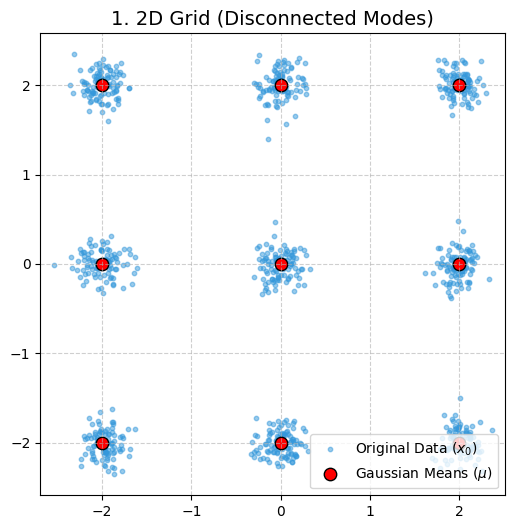

In [ ]:
# ------------------------------------------
# 1. 2D Grid 중심점 생성 및 시각화
# ------------------------------------------
x_grid = np.linspace(-2, 2, 3)  # [-2, 0, 2]
y_grid = np.linspace(-2, 2, 3)  # [-2, 0, 2]

# 모든 (x_grid, y_grid) 조합의 격자, X: x좌표, Y: y좌표를 행렬 형태로 저장
X, Y = np.meshgrid(x_grid, y_grid)  

# .ravel(): 행렬을 1D로 펼침, (3,3) -> (9,)
# column_stack: 열 방향으로 stack -> 원점 (x,y) 좌표 쌍 생성
grid_means = np.column_stack([X.ravel(), Y.ravel()])

# 데이터 샘플링
data_grid = generate_gmm_samples(grid_means, variance=0.02)

# 시각화
plt.figure(figsize=(6, 6))
plt.scatter(data_grid[:, 0], data_grid[:, 1], s=10, alpha=0.5, color='#3498db', label='Original Data ($x_0$)')
plt.scatter(grid_means[:, 0], grid_means[:, 1], color='red', edgecolor='black', s=80, label='Gaussian Means ($\mu$)')
plt.title("1. 2D Grid (Disconnected Modes)", fontsize=14)
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_21323/1902125972.py:23: SyntaxWarning: invalid escape sequence '\m'
  plt.scatter(moon_means[:, 0], moon_means[:, 1], color='red', edgecolor='black', s=80, label='Gaussian Means ($\mu$)')


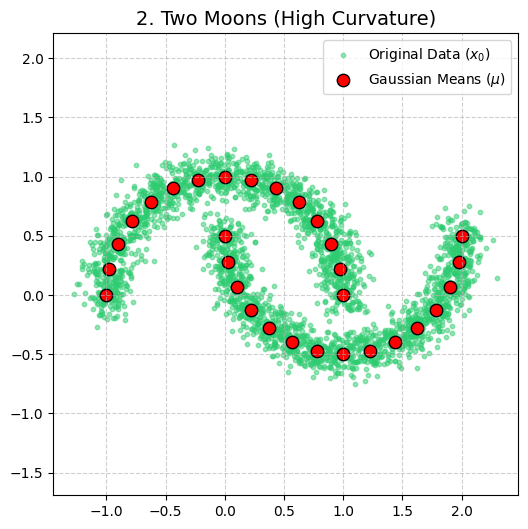

In [ ]:
# ------------------------------------------
# 2. Two Moons 중심점 생성 및 시각화
# ------------------------------------------
theta = np.linspace(0, np.pi, 15)

# 윗쪽 초승달
moon1_x = np.cos(theta)
moon1_y = np.sin(theta)

# 아래쪽 초승달 (방향과 위치를 비틀어 배치)
moon2_x = 1 - np.cos(theta)
moon2_y = 1 - np.sin(theta) - 0.5

# 원점 (x,y) 좌표
moon_means = np.column_stack([np.concatenate([moon1_x, moon2_x]), 
                              np.concatenate([moon1_y, moon2_y])])

# 데이터 샘플링 (분산을 조금 더 작게 하여 달 모양을 뚜렷하게)
data_moons = generate_gmm_samples(moon_means, variance=0.01)

# 시각화
plt.figure(figsize=(6, 6))
plt.scatter(data_moons[:, 0], data_moons[:, 1], s=10, alpha=0.5, color='#2ecc71', label='Original Data ($x_0$)')
plt.scatter(moon_means[:, 0], moon_means[:, 1], color='red', edgecolor='black', s=80, label='Gaussian Means ($\mu$)')
plt.title("2. Two Moons (High Curvature)", fontsize=14)
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_21323/2794513603.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.scatter(heart_means[:, 0], heart_means[:, 1], color='red', edgecolor='black', s=80, label='Gaussian Means ($\mu$)')


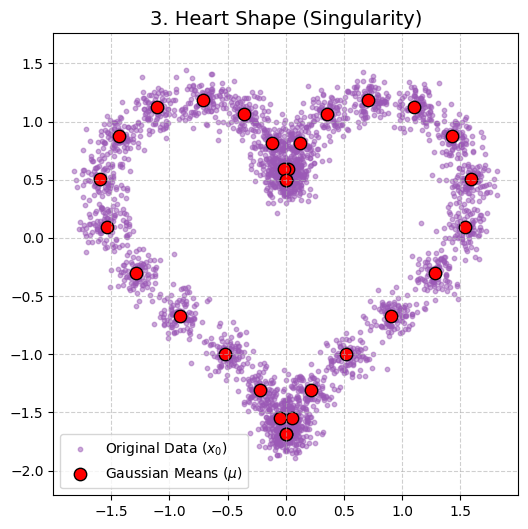

In [14]:
# ------------------------------------------
# 3. Heart Shape 중심점 생성 및 시각화
# ------------------------------------------
t = np.linspace(0, 2 * np.pi, 30)

# 하트 매개변수 방정식
heart_x = 16 * np.sin(t)**3
heart_y = 13 * np.cos(t) - 5 * np.cos(2*t) - 2 * np.cos(3*t) - np.cos(4*t)

# 다른 데이터셋과 스케일(Scale)을 비슷하게 맞추기 위해 크기 축소
heart_means = np.column_stack([heart_x, heart_y]) / 10

# 데이터 샘플링
data_heart = generate_gmm_samples(heart_means, variance=0.01)

# 시각화
plt.figure(figsize=(6, 6))
plt.scatter(data_heart[:, 0], data_heart[:, 1], s=10, alpha=0.5, color='#9b59b6', label='Original Data ($x_0$)')
plt.scatter(heart_means[:, 0], heart_means[:, 1], color='red', edgecolor='black', s=80, label='Gaussian Means ($\mu$)')
plt.title("3. Heart Shape (Singularity)", fontsize=14)
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()